# Notebook 02 · CORINE Land Cover 2018

## Objetivo

En este notebook obtenemos y procesamos los datos de cobertura y uso del suelo de CORINE Land Cover 2018, publicados por Copernicus Land Monitoring Service con una resolución espacial de 100 metros.

Delimitamos el ámbito de estudio a España peninsular, Portugal continental y Andorra. Después cuantificamos las superficies artificiales, agrícolas, forestales y naturales, los humedales y las masas de agua.

También construimos una variable preliminar de compatibilidad del suelo. Esta clasificación ayuda a caracterizar y condicionar el territorio, pero no determina por sí sola la disponibilidad, la propiedad ni la viabilidad final de una parcela para instalar un centro de datos.

In [1]:
# Comprobacion de los datos
from pathlib import Path

INPUT_DIR = Path("/kaggle/input")
rutas_raster_input = list(
    INPUT_DIR.rglob(
        "U2018_CLC2018_V2020_20u1.tif"
    )
)

if rutas_raster_input:

    # Si hay varias copias, utilizamos la ruta más corta.
    rutas_raster_input.sort(
        key=lambda ruta: len(str(ruta))
    )
    ruta_raster_corine = rutas_raster_input[0]
    ruta_raster_corine_europa = ruta_raster_corine
    descargar_corine = False

    print("Raster CORINE encontrado en Kaggle Input.")
    print("No será necesario descargarlo.")
    print("Archivo:", ruta_raster_corine)

else:
    ruta_raster_corine = None
    descargar_corine = True

    print("Raster CORINE no encontrado en Input.")
    print("Se activará la descarga desde CLMS.")

Raster CORINE encontrado en Kaggle Input.
No será necesario descargarlo.
Archivo: /kaggle/input/datasets/aemjeloy/corine-fin/02 corine_2018_completo_raw_procesado_dashboard/raw/raster_europeo_extraido/U2018_CLC2018_V2020_20u1.tif


In [2]:
# instalacionde de librerias
if descargar_corine:
    %pip install -q PyJWT cryptography
    print("Librerías para CLMS instaladas.")
else:
    print(
        "Instalación omitida porque CORINE "
        "ya está disponible en Kaggle Input."
    )

Instalación omitida porque CORINE ya está disponible en Kaggle Input.


In [3]:
# Obtenemos el Token de CLMS
if descargar_corine:
    import json
    import time
    import jwt
    import requests
    from kaggle_secrets import UserSecretsClient

    # Leemos las credenciales guardadas en Kaggle.
    service_key = json.loads(
        UserSecretsClient().get_secret(
            "CLMS_SERVICE_KEY_JSON"
        )
    )
    ahora = int(time.time())

    # Creamos el JWT necesario para solicitar el token.
    grant = jwt.encode(
        {
            "iss": service_key["client_id"],
            "sub": service_key["user_id"],
            "aud": service_key["token_uri"],
            "iat": ahora,
            "exp": ahora + 3600,
        },
        service_key["private_key"].replace(
            "\\n",
            "\n",
        ),
        algorithm="RS256",
        headers={
            "kid": service_key["key_id"]
        },
    )

    # Solicitamos el token temporal.
    respuesta = requests.post(
        service_key["token_uri"],
        data={
            "grant_type": (
                "urn:ietf:params:oauth:"
                "grant-type:jwt-bearer"
            ),
            "assertion": grant,
        },
        timeout=60,
    )
    respuesta.raise_for_status()
    access_token_clms = respuesta.json()[
        "access_token"
    ]
    print("Access token obtenido correctamente.")
else:
    print(
        "Token omitido: CORINE ya está en Input."
    )

Token omitido: CORINE ya está en Input.


In [4]:
# Solicitud de descaega de Corine
if descargar_corine:
    import requests
    respuesta = requests.post(
        (
            "https://land.copernicus.eu/api/"
            "@datarequest_post"
        ),
        headers={
            "Authorization": (
                f"Bearer {access_token_clms}"
            ),
            "Accept": "application/json",
        },
        json={
            "Datasets": [
                {
                    "DatasetID": (
                        "0407d497d3c44bcd93ce8fd5bf78596a"
                    ),
                    "FileID": (
                        "3d9e2413-46ca-4f6e-"
                        "abf8-b6eb429a4e48"
                    ),
                }
            ]
        },
        timeout=120,
    )
    respuesta.raise_for_status()
    task_id_corine = str(
        respuesta.json()["TaskIds"][0]["TaskID"]
    )
    print("Solicitud aceptada.")
    print("TaskID:", task_id_corine)
else:
    print(
        "Solicitud omitida: CORINE ya está en Input."
    )

Solicitud omitida: CORINE ya está en Input.


In [5]:
# descarga del ZIP de Corine
if descargar_corine:
    from pathlib import Path
    import time
    import zipfile
    import requests

    carpeta_corine = Path(
        "/kaggle/working/corine_2018"
    )
    carpeta_corine.mkdir(
        parents=True,
        exist_ok=True,
    )
    ruta_zip_corine = (
        carpeta_corine
        / "corine_land_cover_2018_raster100m_api.zip"
    )

    if not zipfile.is_zipfile(ruta_zip_corine):
        headers = {
            "Authorization": f"Bearer {access_token_clms}",
            "Accept": "application/json",
        }
        download_url_corine = None

        for intento in range(1, 21):

            respuesta = requests.get(
                (
                    "https://land.copernicus.eu/api/"
                    "@datarequest_status_get"
                ),
                headers=headers,
                params={"TaskID": task_id_corine},
                timeout=120,
            )
            if respuesta.status_code == 200:
                estado = respuesta.json()
                print(
                    f"Intento {intento}/20 · "
                    f"{estado.get('Status')}"
                )
                download_url_corine = estado.get(
                    "DownloadURL"
                )
                if download_url_corine:
                    break
            elif respuesta.status_code != 404:
                respuesta.raise_for_status()
            time.sleep(15)

        if not download_url_corine:
            raise RuntimeError(
                "La descarga todavía no está preparada."
            )

        with requests.get(
            download_url_corine,
            headers={
                "Authorization": (
                    f"Bearer {access_token_clms}"
                ),
                "User-Agent": "Mozilla/5.0",
            },
            stream=True,
            timeout=300,
        ) as descarga:
            descarga.raise_for_status()

            with ruta_zip_corine.open("wb") as archivo:
                for bloque in descarga.iter_content(
                    chunk_size=1024 * 1024
                ):
                    archivo.write(bloque)

    if not zipfile.is_zipfile(ruta_zip_corine):
        raise RuntimeError(
            "El archivo descargado no es un ZIP válido."
        )
    print("ZIP de CORINE preparado correctamente.")
else:
    print(
        "Descarga omitida: CORINE ya está en Input."
    )

Descarga omitida: CORINE ya está en Input.


In [6]:
# preparacion del Raster de Corine
from pathlib import Path
import zipfile

if descargar_corine:

    carpeta_extraccion = Path(
        "/kaggle/working/corine_2018/extraido"
    )
    carpeta_extraccion.mkdir(
        parents=True,
        exist_ok=True,
    )

    # Extraemos únicamente el ZIP interno.
    nombre_zip_interno = (
        "Results/"
        "u2018_clc2018_v2020_20u1_raster100m.zip"
    )
    with zipfile.ZipFile(
        ruta_zip_corine
    ) as zip_externo:
        zip_externo.extract(
            nombre_zip_interno,
            carpeta_extraccion,
        )
    ruta_zip_interno = (
        carpeta_extraccion
        / nombre_zip_interno
    )

    # Extraemos únicamente el raster europeo.
    nombre_raster = (
        "u2018_clc2018_v2020_20u1_raster100m/"
        "DATA/U2018_CLC2018_V2020_20u1.tif"
    )
    with zipfile.ZipFile(
        ruta_zip_interno
    ) as zip_interno:
        zip_interno.extract(
            nombre_raster,
            carpeta_extraccion,
        )
    ruta_raster_corine = (
        carpeta_extraccion
        / nombre_raster
    )
    print("Raster extraído desde el ZIP de CLMS.")

else:
    ruta_raster_corine = Path(
        ruta_raster_corine
    )
    print("Se utiliza el raster de Kaggle Input.")
if not ruta_raster_corine.exists():
    raise FileNotFoundError(
        "No se encuentra el raster CORINE."
    )
ruta_raster_corine_europa = ruta_raster_corine
print("Raster CORINE preparado correctamente.")
print("Archivo:", ruta_raster_corine)

Se utiliza el raster de Kaggle Input.
Raster CORINE preparado correctamente.
Archivo: /kaggle/input/datasets/aemjeloy/corine-fin/02 corine_2018_completo_raw_procesado_dashboard/raw/raster_europeo_extraido/U2018_CLC2018_V2020_20u1.tif


In [7]:
# inspeccion del raster de Corine
import rasterio

with rasterio.open(ruta_raster_corine) as src:

    # Algunos GeoTIFF antiguos no devuelven el EPSG directamente.
    epsg_corine = src.crs.to_epsg()
    if (
        epsg_corine is None
        and 'AUTHORITY["EPSG","3035"]'
        in src.crs.to_wkt()
    ):
        epsg_corine = 3035

    print("EPSG:", epsg_corine)
    print("Resolución:", src.res)
    print("Dimensiones:", src.width, "x", src.height)
    print("Bandas:", src.count)
    print("Tipo de dato:", src.dtypes[0])
    print("NoData:", src.nodata)
    print("Extensión:", src.bounds)

    if epsg_corine != 3035:
        raise RuntimeError(
            "El CRS esperado es EPSG:3035."
        )
    if src.res != (100.0, 100.0):
        raise RuntimeError(
            "La resolución esperada es de 100 metros."
        )
    if src.count != 1:
        raise RuntimeError(
            "El raster debe tener una única banda."
        )
print("Raster CORINE validado correctamente.")

EPSG: 3035
Resolución: (100.0, 100.0)
Dimensiones: 65000 x 46000
Bandas: 1
Tipo de dato: int8
NoData: -128.0
Extensión: BoundingBox(left=900000.0, bottom=900000.0, right=7400000.0, top=5500000.0)
Raster CORINE validado correctamente.


In [8]:
# Pre-recorte de Corine en la parte Iberica
from pathlib import Path
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

carpeta_procesado = Path(
    "/kaggle/working/corine_2018/procesado"
)
carpeta_procesado.mkdir(
    parents=True,
    exist_ok=True,
)
ruta_raster_corine_iberia_bbox = (
    carpeta_procesado
    / "corine_2018_iberia_bbox_100m.tif"
)

# Límites aproximados de la zona ibérica.
bbox_iberia = (-10.0, 35.0, 4.0, 44.0)
if not ruta_raster_corine_iberia_bbox.exists():
    with rasterio.open(ruta_raster_corine) as src:
        limites = transform_bounds(
            "EPSG:4326",
            src.crs,
            *bbox_iberia,
            densify_pts=21,
        )
        ventana = from_bounds(
            *limites,
            transform=src.transform,
        ).round_offsets().round_lengths()
        datos = src.read(1, window=ventana)
        perfil = src.profile.copy()
        perfil.update(
            height=datos.shape[0],
            width=datos.shape[1],
            transform=src.window_transform(ventana),
            compress="lzw",
        )
    with rasterio.open(
        ruta_raster_corine_iberia_bbox,
        "w",
        **perfil,
    ) as dst:
        dst.write(datos, 1)
    print("Pre-recorte generado correctamente.")
else:
    print("Se reutiliza el pre-recorte existente.")
ruta_raster_corine_iberia = (
    ruta_raster_corine_iberia_bbox
)

with rasterio.open(
    ruta_raster_corine_iberia_bbox
) as src:
    if (
        src.count != 1
        or src.res != (100.0, 100.0)
        or src.nodata != -128
    ):
        raise RuntimeError(
            "El pre-recorte no tiene las propiedades esperadas."
        )

    print("Dimensiones:", src.width, "x", src.height)
    print("Resolución:", src.res)
    print("Archivo:", ruta_raster_corine_iberia_bbox)

Pre-recorte generado correctamente.
Dimensiones: 13407 x 11856
Resolución: (100.0, 100.0)
Archivo: /kaggle/working/corine_2018/procesado/corine_2018_iberia_bbox_100m.tif


In [9]:
# recorte territorial de Corine
import geopandas as gpd
import rasterio
from rasterio.mask import mask

# Localizamos el límite territorial preparado.
rutas_ambito = list(
    INPUT_DIR.rglob(
        "ambito_iberia_continental_andorra.geojson"
    )
)
if not rutas_ambito:
    raise FileNotFoundError(
        "No se encuentra el límite territorial en Input."
    )
ruta_vector_ambito_corine = rutas_ambito[0]
ambito = gpd.read_file(
    ruta_vector_ambito_corine
)
ruta_raster_corine_iberia_final = (
    carpeta_procesado
    / "corine_2018_iberia_continental_andorra_100m.tif"
)

# Aplicamos la máscara territorial.
with rasterio.open(
    ruta_raster_corine_iberia_bbox
) as src:
    ambito = ambito.to_crs(src.crs)
    datos, transformacion = mask(
        src,
        ambito.geometry,
        crop=True,
        nodata=src.nodata,
    )
    perfil = src.profile.copy()
    perfil.update(
        height=datos.shape[1],
        width=datos.shape[2],
        transform=transformacion,
        compress="lzw",
    )
with rasterio.open(
    ruta_raster_corine_iberia_final,
    "w",
    **perfil,
) as dst:
    dst.write(datos)

# Alias utilizado en las celdas posteriores.
ruta_raster_corine_iberia = (
    ruta_raster_corine_iberia_final
)
with rasterio.open(
    ruta_raster_corine_iberia_final
) as src:
    print("Dimensiones:", src.width, "x", src.height)
    print("Resolución:", src.res)
    print("NoData:", src.nodata)

print("Recorte territorial finalizado.")
print("Archivo:", ruta_raster_corine_iberia_final)

Dimensiones: 11338 x 8855
Resolución: (100.0, 100.0)
NoData: -128.0
Recorte territorial finalizado.
Archivo: /kaggle/working/corine_2018/procesado/corine_2018_iberia_continental_andorra_100m.tif


In [10]:
# revision de codigos Corine
import numpy as np
import pandas as pd
import rasterio

with rasterio.open(
    ruta_raster_corine_iberia_final
) as src:
    datos_validos = src.read(
        1,
        masked=True,
    ).compressed()

    area_pixel_km2 = (
        src.res[0] * src.res[1] / 1_000_000
    )
valores_unicos_corine_final, conteos_corine_final = (
    np.unique(
        datos_validos,
        return_counts=True,
    )
)
total_pixeles_validos = (
    conteos_corine_final.sum()
)
tabla_codigos_corine_final = pd.DataFrame(
    {
        "codigo_corine": valores_unicos_corine_final,
        "pixeles": conteos_corine_final,
        "area_km2": (
            conteos_corine_final * area_pixel_km2
        ).round(2),
        "porcentaje": (
            conteos_corine_final
            / total_pixeles_validos
            * 100
        ).round(4),
    }
)
print("Píxeles válidos:", total_pixeles_validos)
print("Códigos encontrados:", valores_unicos_corine_final)

display(tabla_codigos_corine_final)

Píxeles válidos: 58265008
Códigos encontrados: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 48]


,codigo_corine,pixeles,area_km2,porcentaje
0,1,230482,2304.82,0.3956
1,2,698861,6988.61,1.1995
2,3,296648,2966.48,0.5091
3,4,62767,627.67,0.1077
4,5,5933,59.33,0.0102
5,6,23371,233.71,0.0401
6,7,94204,942.04,0.1617
7,8,14394,143.94,0.0247
8,9,28548,285.48,0.0490
9,10,20712,207.12,0.0355


In [11]:
# clasificacion de las clases Corine
import pandas as pd

ARTIFICIAL = "Superficies artificiales"
AGRICOLA = "Superficies agrícolas"
NATURAL = "Zonas forestales y naturales"
HUMEDAL = "Humedales"
AGUA = "Masas de agua"
REVISAR = "Código adicional / revisar"
leyenda_corine = [
    (1, 111, "Tejido urbano continuo", ARTIFICIAL),
    (2, 112, "Tejido urbano discontinuo", ARTIFICIAL),
    (3, 121, "Zonas industriales o comerciales", ARTIFICIAL),
    (4, 122, "Redes viarias y ferroviarias", ARTIFICIAL),
    (5, 123, "Zonas portuarias", ARTIFICIAL),
    (6, 124, "Aeropuertos", ARTIFICIAL),
    (7, 131, "Zonas de extracción minera", ARTIFICIAL),
    (8, 132, "Escombreras y vertederos", ARTIFICIAL),
    (9, 133, "Zonas en construcción", ARTIFICIAL),
    (10, 141, "Zonas verdes urbanas", ARTIFICIAL),
    (11, 142, "Instalaciones deportivas y recreativas", ARTIFICIAL),

    (12, 211, "Tierras de labor en secano", AGRICOLA),
    (13, 212, "Terrenos regados permanentemente", AGRICOLA),
    (14, 213, "Arrozales", AGRICOLA),
    (15, 221, "Viñedos", AGRICOLA),
    (16, 222, "Frutales y plantaciones de bayas", AGRICOLA),
    (17, 223, "Olivares", AGRICOLA),
    (18, 231, "Praderas", AGRICOLA),
    (19, 241, "Cultivos anuales y permanentes", AGRICOLA),
    (20, 242, "Mosaico de cultivos", AGRICOLA),
    (21, 243, "Agricultura con vegetación natural", AGRICOLA),
    (22, 244, "Sistemas agroforestales", AGRICOLA),

    (23, 311, "Bosques de frondosas", NATURAL),
    (24, 312, "Bosques de coníferas", NATURAL),
    (25, 313, "Bosque mixto", NATURAL),
    (26, 321, "Pastizales naturales", NATURAL),
    (27, 322, "Landas y matorrales", NATURAL),
    (28, 323, "Vegetación esclerófila", NATURAL),
    (29, 324, "Matorral boscoso de transición", NATURAL),
    (30, 331, "Playas, dunas y arenales", NATURAL),
    (31, 332, "Roquedo", NATURAL),
    (32, 333, "Espacios con vegetación escasa", NATURAL),
    (33, 334, "Zonas quemadas", NATURAL),
    (34, 335, "Glaciares y nieves permanentes", NATURAL),

    (35, 411, "Marismas interiores", HUMEDAL),
    (36, 412, "Turberas", HUMEDAL),
    (37, 421, "Marismas marítimas", HUMEDAL),
    (38, 422, "Salinas", HUMEDAL),
    (39, 423, "Zonas intermareales", HUMEDAL),

    (40, 511, "Cursos de agua", AGUA),
    (41, 512, "Láminas de agua", AGUA),
    (42, 521, "Lagunas costeras", AGUA),
    (43, 522, "Estuarios", AGUA),
    (44, 523, "Mares y océanos", AGUA),

    (
        48,
        None,
        "Código adicional pendiente de revisión",
        REVISAR,
    ),
]

tabla_leyenda_corine = pd.DataFrame(
    leyenda_corine,
    columns=[
        "codigo_corine",
        "codigo_clc",
        "clase_corine",
        "grupo_corine",
    ],
)

# Añadimos la descripción de cada clase.
tabla_codigos_corine_clasificada = (
    tabla_codigos_corine_final.merge(
        tabla_leyenda_corine,
        on="codigo_corine",
        how="left",
    )
)
if tabla_codigos_corine_clasificada[
    "clase_corine"
].isna().any():
    raise RuntimeError(
        "Existen códigos CORINE sin clasificar."
    )

# Resumen provisional por grandes grupos.
tabla_grupos_corine_final = (
    tabla_codigos_corine_clasificada
    .groupby(
        "grupo_corine",
        as_index=False,
    )
    .agg(
        pixeles=("pixeles", "sum"),
        area_km2=("area_km2", "sum"),
    )
)
total_pixeles = tabla_grupos_corine_final[
    "pixeles"
].sum()

tabla_grupos_corine_final["porcentaje"] = (
    tabla_grupos_corine_final["pixeles"]
    / total_pixeles
    * 100
).round(4)

tabla_grupos_corine_final = (
    tabla_grupos_corine_final
    .sort_values(
        "area_km2",
        ascending=False,
    )
    .reset_index(drop=True)
)
display(tabla_codigos_corine_clasificada)
display(tabla_grupos_corine_final)

print(
    "Clasificación provisional completada. "
    "El código 48 queda pendiente de revisión."
)

,codigo_corine,pixeles,area_km2,porcentaje,codigo_clc,clase_corine,grupo_corine
0,1,230482,2304.82,0.3956,111.0,Tejido urbano continuo,Superficies artificiales
1,2,698861,6988.61,1.1995,112.0,Tejido urbano discontinuo,Superficies artificiales
2,3,296648,2966.48,0.5091,121.0,Zonas industriales o comerciales,Superficies artificiales
3,4,62767,627.67,0.1077,122.0,Redes viarias y ferroviarias,Superficies artificiales
4,5,5933,59.33,0.0102,123.0,Zonas portuarias,Superficies artificiales
5,6,23371,233.71,0.0401,124.0,Aeropuertos,Superficies artificiales
6,7,94204,942.04,0.1617,131.0,Zonas de extracción minera,Superficies artificiales
7,8,14394,143.94,0.0247,132.0,Escombreras y vertederos,Superficies artificiales
8,9,28548,285.48,0.0490,133.0,Zonas en construcción,Superficies artificiales
9,10,20712,207.12,0.0355,141.0,Zonas verdes urbanas,Superficies artificiales


,grupo_corine,pixeles,area_km2,porcentaje
0,Superficies agrícolas,28108860,281088.60,48.2431
1,Zonas forestales y naturales,27916825,279168.25,47.9135
2,Superficies artificiales,1530360,15303.60,2.6266
3,Masas de agua,547949,5479.49,0.9404
4,Humedales,120652,1206.52,0.2071
5,Código adicional / revisar,40362,403.62,0.0693


Clasificación provisional completada. El código 48 queda pendiente de revisión.


In [12]:
# comprobacion del Codigo Corine 48
rutas_leyenda = list(
    INPUT_DIR.rglob(
        "clc_legend_qgis_raster.qml"
    )
)
if not rutas_leyenda:
    raise FileNotFoundError(
        "No se encuentra la leyenda QGIS de CORINE."
    )

# Priorizamos la leyenda europea frente a French_DOMs.
rutas_leyenda.sort(
    key=lambda ruta: (
        "french_doms" in str(ruta).lower(),
        len(str(ruta)),
    )
)
ruta_leyenda_corine = rutas_leyenda[0]
linea_codigo_48 = None

for linea in ruta_leyenda_corine.read_text(
    encoding="utf-8",
    errors="ignore",
).splitlines():
    if 'value="48"' in linea:
        linea_codigo_48 = linea.strip()
        break
if (
    linea_codigo_48 is None
    or "999 - NODATA" not in linea_codigo_48
):
    raise RuntimeError(
        "No se ha podido identificar el código 48."
    )

print("Leyenda utilizada:", ruta_leyenda_corine)
print("Entrada encontrada:")
print(linea_codigo_48)
print("Conclusión: código 48 = 999 - NODATA.")

Leyenda utilizada: /kaggle/input/datasets/aemjeloy/corine-fin/02 corine_2018_completo_raw_procesado_dashboard/raw/copernicus_clms/corine_land_cover_2018_raster100m_api/Results/u2018_clc2018_v2020_20u1_raster100m/u2018_clc2018_v2020_20u1_raster100m/Legend/clc_legend_qgis_raster.qml
Entrada encontrada:
<paletteEntry color="#ffffff" label="999 - NODATA" value="48" alpha="255"/>
Conclusión: código 48 = 999 - NODATA.


In [13]:
# Excluir el codigo 48 y crear tablas definitivas
tabla_codigos_corine_analisis = (
    tabla_codigos_corine_clasificada
    .query("codigo_corine != 48")
    .drop(columns="porcentaje", errors="ignore")
    .copy()
)
tabla_codigos_corine_analisis["codigo_clc"] = (
    tabla_codigos_corine_analisis["codigo_clc"]
    .astype(int)
)
total_pixeles_analisis = (
    tabla_codigos_corine_analisis["pixeles"].sum()
)
total_area_analisis_km2 = (
    tabla_codigos_corine_analisis["area_km2"].sum()
)
tabla_codigos_corine_analisis[
    "porcentaje_area_analisis"
] = (
    tabla_codigos_corine_analisis["pixeles"]
    / total_pixeles_analisis
    * 100
).round(4)

tabla_grupos_corine_analisis = (
    tabla_codigos_corine_analisis
    .groupby("grupo_corine", as_index=False)
    .agg(
        pixeles=("pixeles", "sum"),
        area_km2=("area_km2", "sum"),
    )
    .sort_values("area_km2", ascending=False)
    .reset_index(drop=True)
)
tabla_grupos_corine_analisis[
    "porcentaje_area_analisis"
] = (
    tabla_grupos_corine_analisis["pixeles"]
    / total_pixeles_analisis
    * 100
).round(4)
ruta_tabla_codigos_corregida = (
    carpeta_procesado
    / "tabla_codigos_corine_iberia_final_sin_nodata_auxiliar.csv"
)
ruta_tabla_grupos_corregida = (
    carpeta_procesado
    / "tabla_grupos_corine_iberia_final_sin_nodata_auxiliar.csv"
)
tabla_codigos_corine_analisis.to_csv(
    ruta_tabla_codigos_corregida,
    index=False,
)
tabla_grupos_corine_analisis.to_csv(
    ruta_tabla_grupos_corregida,
    index=False,
)
print("Píxeles analizados:", total_pixeles_analisis)
print("Área analizada:", total_area_analisis_km2, "km²")

display(tabla_grupos_corine_analisis)

Píxeles analizados: 58224646
Área analizada: 582246.46 km²


,grupo_corine,pixeles,area_km2,porcentaje_area_analisis
0,Superficies agrícolas,28108860,281088.60,48.2766
1,Zonas forestales y naturales,27916825,279168.25,47.9467
2,Superficies artificiales,1530360,15303.60,2.6284
3,Masas de agua,547949,5479.49,0.9411
4,Humedales,120652,1206.52,0.2072


In [14]:
# Resumen Corine Terrestre
tabla_corine_terrestre_analisis = (
    tabla_codigos_corine_analisis
    .query("codigo_corine != 44")
    .drop(columns="porcentaje_area_analisis")
    .copy()
)
total_pixeles_terrestres = (
    tabla_corine_terrestre_analisis["pixeles"].sum()
)
superficie_terrestre_total_km2 = (
    total_pixeles_terrestres * area_pixel_km2
)
tabla_corine_terrestre_analisis["porcentaje_sobre_tierra"] = (
    tabla_corine_terrestre_analisis["pixeles"]
    / total_pixeles_terrestres
    * 100
).round(4)

tabla_grupos_corine_terrestre = (
    tabla_corine_terrestre_analisis
    .groupby("grupo_corine", as_index=False)
    .agg(
        pixeles=("pixeles", "sum"),
        area_km2=("area_km2", "sum"),
    )
    .sort_values("area_km2", ascending=False)
    .reset_index(drop=True)
)
tabla_grupos_corine_terrestre["porcentaje_sobre_tierra"] = (
    tabla_grupos_corine_terrestre["pixeles"]
    / total_pixeles_terrestres
    * 100
).round(4)

ruta_tabla_corine_terrestre = (
    carpeta_procesado
    / "tabla_codigos_corine_iberia_terrestre_sin_mar.csv"
)
ruta_tabla_grupos_corine_terrestre = (
    carpeta_procesado
    / "tabla_grupos_corine_iberia_terrestre_sin_mar.csv"
)
tabla_corine_terrestre_analisis.to_csv(
    ruta_tabla_corine_terrestre,
    index=False,
)
tabla_grupos_corine_terrestre.to_csv(
    ruta_tabla_grupos_corine_terrestre,
    index=False,
)
print("Píxeles terrestres:", total_pixeles_terrestres)
print("Superficie terrestre:", superficie_terrestre_total_km2, "km²")

display(tabla_grupos_corine_terrestre)

Píxeles terrestres: 58109304
Superficie terrestre: 581093.04 km²


,grupo_corine,pixeles,area_km2,porcentaje_sobre_tierra
0,Superficies agrícolas,28108860,281088.60,48.3724
1,Zonas forestales y naturales,27916825,279168.25,48.0419
2,Superficies artificiales,1530360,15303.60,2.6336
3,Masas de agua,432607,4326.07,0.7445
4,Humedales,120652,1206.52,0.2076


In [15]:
# Compatibilidad preliminar del suelo
import numpy as np
import rasterio

niveles_compatibilidad = {
    0: [
        30, 34, 35, 36, 37, 38,
        39, 40, 41, 42, 43, 44,
    ],
    1: [
        1, 5, 6, 10, 14, 22, 23, 24,
        25, 26, 27, 28, 29, 31, 32, 33,
    ],
    2: [
        2, 7, 8, 11, 12, 13, 15,
        16, 17, 18, 19, 20, 21,
    ],
    3: [3, 4, 9],
}
ruta_raster_compatibilidad_corine = (
    carpeta_procesado
    / "corine_2018_iberia_compatibilidad_suelo_cpd.tif"
)

with rasterio.open(
    ruta_raster_corine_iberia_final
) as src:
    datos = src.read(1)
    perfil = src.profile.copy()
compatibilidad = np.full(
    datos.shape,
    255,
    dtype=np.uint8,
)
for nivel, codigos in niveles_compatibilidad.items():
    compatibilidad[
        np.isin(datos, codigos)
    ] = nivel
perfil.update(
    dtype="uint8",
    nodata=255,
    compress="lzw",
)
with rasterio.open(
    ruta_raster_compatibilidad_corine,
    "w",
    **perfil,
) as dst:
    dst.write(compatibilidad, 1)
print(
    "Raster de compatibilidad guardado:",
    ruta_raster_compatibilidad_corine,
)

Raster de compatibilidad guardado: /kaggle/working/corine_2018/procesado/corine_2018_iberia_compatibilidad_suelo_cpd.tif


In [16]:
# Resumen de compatibilidad preliminar
nombres_compatibilidad = {
    0: "Excluido por cobertura del suelo",
    1: "Compatibilidad baja o condicionada",
    2: "Compatibilidad media",
    3: "Compatibilidad alta preliminar",
}
with rasterio.open(
    ruta_raster_compatibilidad_corine
) as src:
    datos_validos = src.read(
        1,
        masked=True,
    ).compressed()

    area_pixel_km2 = (
        src.res[0] * src.res[1] / 1_000_000
    )
valores_comp, conteos_comp = np.unique(
    datos_validos,
    return_counts=True,
)
total_pixeles_comp = conteos_comp.sum()
tabla_compatibilidad_corine = pd.DataFrame(
    {
        "valor_compatibilidad": valores_comp,
        "descripcion": [
            nombres_compatibilidad[int(valor)]
            for valor in valores_comp
        ],
        "pixeles": conteos_comp,
        "superficie_km2": (
            conteos_comp * area_pixel_km2
        ).round(2),
        "porcentaje_area_analisis": (
            conteos_comp
            / total_pixeles_comp
            * 100
        ).round(4),
    }
)
ruta_resumen_compatibilidad_corine = (
    carpeta_procesado
    / "tabla_resumen_compatibilidad_suelo_corine_iberia_2018.csv"
)
tabla_compatibilidad_corine.to_csv(
    ruta_resumen_compatibilidad_corine,
    index=False,
)
print("Píxeles analizados:", total_pixeles_comp)
display(tabla_compatibilidad_corine)

Píxeles analizados: 58224646


,valor_compatibilidad,descripcion,pixeles,superficie_km2,porcentaje_area_analisis
0,0,Excluido por cobertura del suelo,696740,6967.40,1.1966
1,1,Compatibilidad baja o condicionada,31490522,314905.22,54.0845
2,2,Compatibilidad media,25649421,256494.21,44.0525
3,3,Compatibilidad alta preliminar,387963,3879.63,0.6663


In [17]:
# Carpetas para visualizaciones
CARPETA_DASHBOARD_CORINE = (
    carpeta_procesado.parent / "dashboard"
)
CARPETA_FIGURAS_CORINE = (
    CARPETA_DASHBOARD_CORINE / "figuras"
)
CARPETA_MAPAS_CORINE = (
    CARPETA_DASHBOARD_CORINE / "mapas"
)

for carpeta in [
    CARPETA_DASHBOARD_CORINE,
    CARPETA_FIGURAS_CORINE,
    CARPETA_MAPAS_CORINE,
]:
    carpeta.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Carpetas de visualización preparadas.")

Carpetas de visualización preparadas.


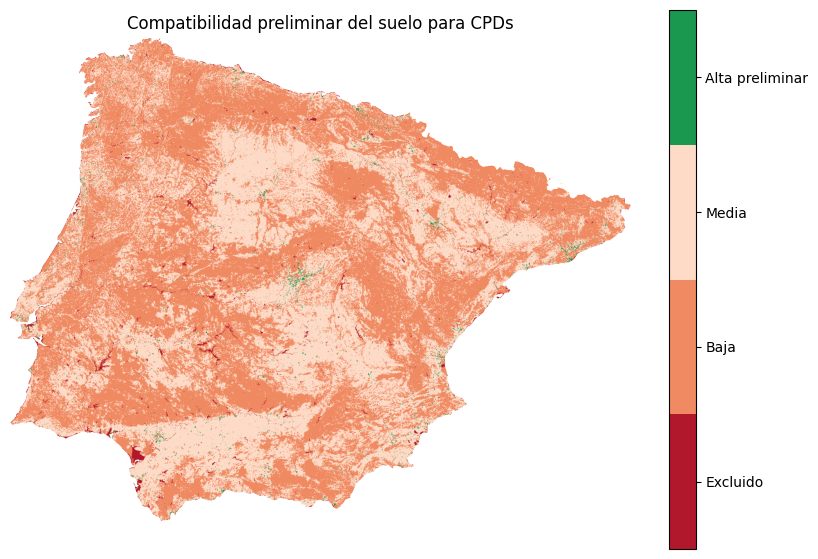

Mapa guardado: /kaggle/working/corine_2018/dashboard/mapas/mapa_compatibilidad_suelo_corine_iberia.png


In [18]:
# mapa de compatibilidad preliminar
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.enums import Resampling

ruta_mapa_compatibilidad_png = (
    CARPETA_MAPAS_CORINE
    / "mapa_compatibilidad_suelo_corine_iberia.png"
)
with rasterio.open(
    ruta_raster_compatibilidad_corine
) as src:
    datos_mapa = src.read(
        1,
        out_shape=(
            src.height // 8,
            src.width // 8,
        ),
        resampling=Resampling.nearest,
        masked=True,
    )
cmap = ListedColormap(
    ["#b2182b", "#ef8a62", "#fddbc7", "#1a9850"]
)
cmap.set_bad("white", alpha=0)
fig, ax = plt.subplots(figsize=(10, 7))
mapa = ax.imshow(
    datos_mapa,
    cmap=cmap,
    vmin=-0.5,
    vmax=3.5,
)
ax.set_title(
    "Compatibilidad preliminar del suelo para CPDs"
)
ax.axis("off")
barra = fig.colorbar(
    mapa,
    ax=ax,
    ticks=[0, 1, 2, 3],
)
barra.ax.set_yticklabels(
    ["Excluido", "Baja", "Media", "Alta preliminar"]
)
fig.savefig(
    ruta_mapa_compatibilidad_png,
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close(fig)
print("Mapa guardado:", ruta_mapa_compatibilidad_png)

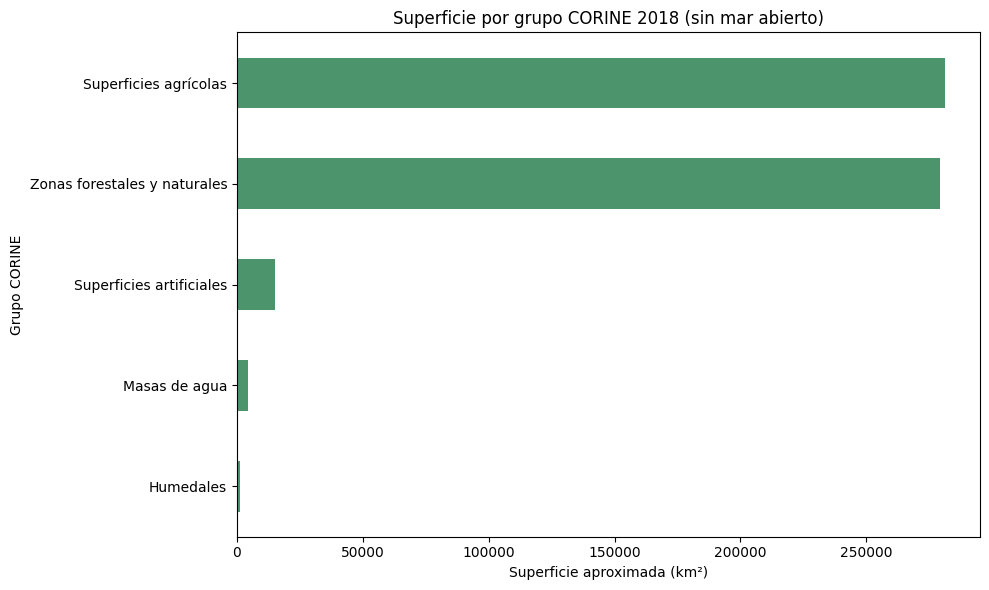

Gráfico guardado: /kaggle/working/corine_2018/dashboard/figuras/grafico_grupos_corine_terrestre.png


In [19]:
# Superficie por grupo Corine sin mar abierto
ruta_grafico_grupos_png = (
    CARPETA_FIGURAS_CORINE
    / "grafico_grupos_corine_terrestre.png"
)

ax = (
    tabla_grupos_corine_terrestre
    .set_index("grupo_corine")["area_km2"]
    .sort_values()
    .plot.barh(
        figsize=(10, 6),
        color="#4c956c",
    )
)

ax.set_title(
    "Superficie por grupo CORINE 2018 (sin mar abierto)"
)
ax.set_xlabel("Superficie aproximada (km²)")
ax.set_ylabel("Grupo CORINE")

plt.tight_layout()
plt.savefig(
    ruta_grafico_grupos_png,
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()

print("Gráfico guardado:", ruta_grafico_grupos_png)

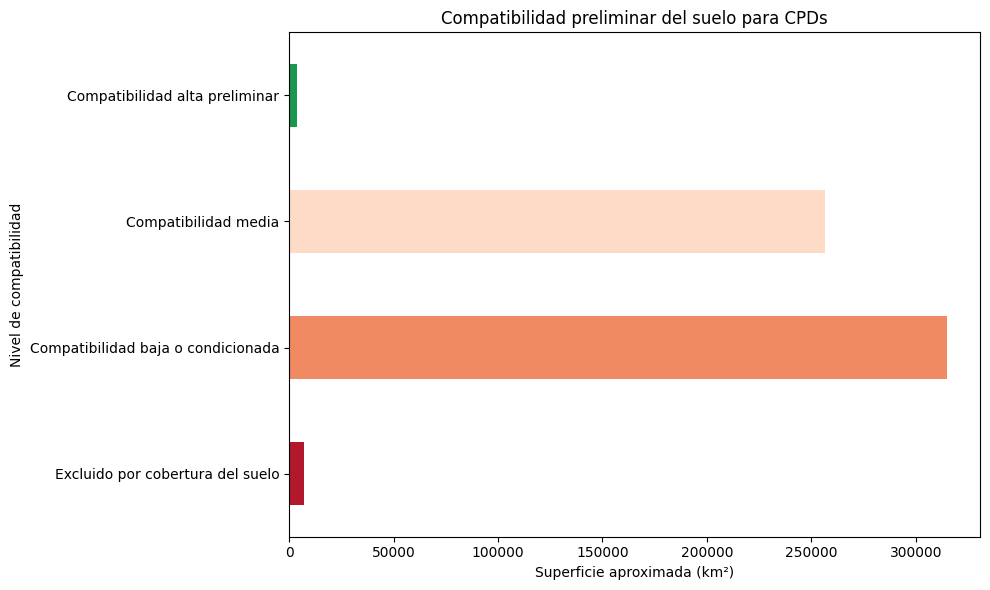

Gráfico guardado: /kaggle/working/corine_2018/dashboard/figuras/grafico_compatibilidad_suelo_corine.png


In [20]:
# grafico de compatibilidad preliminar
ruta_grafico_compatibilidad_png = (
    CARPETA_FIGURAS_CORINE
    / "grafico_compatibilidad_suelo_corine.png"
)
tabla_comp_ordenada = (
    tabla_compatibilidad_corine
    .sort_values("valor_compatibilidad")
)
ax = (
    tabla_comp_ordenada
    .set_index("descripcion")["superficie_km2"]
    .plot.barh(
        figsize=(10, 6),
        color=[
            "#b2182b",
            "#ef8a62",
            "#fddbc7",
            "#1a9850",
        ],
    )
)
ax.set_title(
    "Compatibilidad preliminar del suelo para CPDs"
)
ax.set_xlabel("Superficie aproximada (km²)")
ax.set_ylabel("Nivel de compatibilidad")
plt.tight_layout()
plt.savefig(
    ruta_grafico_compatibilidad_png,
    dpi=200,
    bbox_inches="tight",
)
plt.show()
plt.close()
print(
    "Gráfico guardado:",
    ruta_grafico_compatibilidad_png,
)

In [21]:
# dasboard HTML
ruta_dashboard_html = (
    CARPETA_DASHBOARD_CORINE
    / "dashboard_corine_iberia_2018.html"
)

contenido_html = f"""
<html lang="es">
<head>
<meta charset="UTF-8">
<title>Dashboard CORINE 2018</title>
<style>
body {{font-family: Arial; max-width: 1100px; margin: auto;}}
img {{max-width: 100%;}}
table {{width: 100%; border-collapse: collapse;}}
th, td {{border: 1px solid #ccc; padding: 6px;}}
</style>
</head>
<body>

<h1>CORINE Land Cover 2018 · Ámbito ibérico</h1>

<p>
España peninsular, Portugal continental y Andorra.
La compatibilidad representada es preliminar y no determina
por sí sola la aptitud final para instalar un centro de datos.
</p>

<h2>Mapa de compatibilidad</h2>
<img src="mapas/{ruta_mapa_compatibilidad_png.name}">

<h2>Superficie por grupos CORINE</h2>
<img src="figuras/{ruta_grafico_grupos_png.name}">

<h2>Compatibilidad preliminar</h2>
<img src="figuras/{ruta_grafico_compatibilidad_png.name}">

<h2>Resumen por grupos CORINE sin mar abierto</h2>
{tabla_grupos_corine_terrestre.to_html(index=False)}

<h2>Resumen de compatibilidad</h2>
{tabla_compatibilidad_corine.to_html(index=False)}

</body>
</html>
"""

ruta_dashboard_html.write_text(
    contenido_html,
    encoding="utf-8",
)

print("Dashboard guardado:", ruta_dashboard_html)

Dashboard guardado: /kaggle/working/corine_2018/dashboard/dashboard_corine_iberia_2018.html


In [22]:
# ZIP final
import zipfile

archivos_finales = [
    (ruta_raster_corine_iberia_final, "datos"),
    (ruta_raster_compatibilidad_corine, "datos"),
    (ruta_vector_ambito_corine, "datos"),
    (ruta_tabla_codigos_corregida, "tablas"),
    (ruta_tabla_grupos_corregida, "tablas"),
    (ruta_tabla_corine_terrestre, "tablas"),
    (ruta_tabla_grupos_corine_terrestre, "tablas"),
    (ruta_resumen_compatibilidad_corine, "tablas"),
    (ruta_mapa_compatibilidad_png, "dashboard/mapas"),
    (ruta_grafico_grupos_png, "dashboard/figuras"),
    (ruta_grafico_compatibilidad_png, "dashboard/figuras"),
    (ruta_dashboard_html, "dashboard"),
]
faltantes = [
    ruta for ruta, _ in archivos_finales
    if not ruta.exists()
]
if faltantes:
    raise FileNotFoundError(
        "Faltan archivos:\n"
        + "\n".join(map(str, faltantes))
    )
ruta_zip_corine_definitivo = Path(
    "/kaggle/working/"
    "corine_2018_procesado_iberia_2018_final_definitivo.zip"
)
with zipfile.ZipFile(
    ruta_zip_corine_definitivo,
    "w",
    zipfile.ZIP_DEFLATED,
) as archivo_zip:
    for ruta, carpeta in archivos_finales:
        archivo_zip.write(
            ruta,
            arcname=f"{carpeta}/{ruta.name}",
        )
tamano_mb = (
    ruta_zip_corine_definitivo.stat().st_size
    / 1024**2
)
print("ZIP definitivo:", ruta_zip_corine_definitivo)
print("Archivos incluidos:", len(archivos_finales))
print("Tamaño:", round(tamano_mb, 2), "MB")

ZIP definitivo: /kaggle/working/corine_2018_procesado_iberia_2018_final_definitivo.zip
Archivos incluidos: 12
Tamaño: 14.8 MB
